<a href="https://colab.research.google.com/github/abdullah2709/EAAI_Project/blob/main/BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Personality Analysis using Machine Learning and Data Mining**

# [1] Introduction

*# Guled's changes*

The purpose of this project was to investigate how customers behave and forecast the reaction to a marketing campaign for a retail client who has a limited contact budget. The business issue here is that the target is inefficient.

The marketing team need an effective method to prioritize customers for the next campaign as well as customize messages and offers to each type of customer.

We used the "Customer Personality Analysis" dataset from kaggle.com. This dataset had 2,240 customer records and 29 variables. Each row in the data represented one customer. The columns contained demographic information and income, household composition, customer enrollment date, recency (the time since last interaction), spending across product categories, number of purchases made by channel, whether or not they accepted the previous campaign, if they filed complaints and a binary response variable for the most recent campaign.

This project answered three questions:

1. What customer segments exist based on their value, recency, purchase frequency and behavior by channel.

2. What were the strongest correlations to campaign response.

3. Who are the best customers to pursue with a ranked list based on the predicted likelihood of responding.

# [2] Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# [3] Load Dataset

In [ ]:
url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"

In [ ]:
df = pd.read_csv(url, sep='\t')
df.head()
df.tail()
display(df.info())
display(df.describe())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


# [4]. Data Cleaning & Feature Engineering

The start records the dataset size and missing values before cleaning for a comparison after

In [ ]:
# Guled's changes

print("Start of Part 4 shape:", df.shape)
print("Top missing columns before:\n", df.isna().sum().sort_values(ascending=False).head(15))

Start of Part 4 shape: (2240, 29)
Top missing columns before:
 Income              24
ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
dtype: int64


**Create Age Feature**

This section creates a reproducible age feature using the dataset timeline, then caps unrealistic ages.

In [ ]:
# Guled's changes

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
df["Year_Birth"] = pd.to_numeric(df["Year_Birth"], errors="coerce")

as_of = df["Dt_Customer"].max()
df["Age"] = as_of.year - df["Year_Birth"]
df["Age"] = df["Age"].clip(lower=18, upper=100)

print("Age reference date:", as_of.date())
print("Age min/max:", df["Age"].min(), df["Age"].max())

Age reference date: 2014-06-29
Age min/max: 18 100


**Convert Date Column**

This Converts Dt_Customer to datetime and shows how many rows ended up failing parsing.

In [ ]:
# Guled's changes
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
print("Null Dt_Customer:", int(df["Dt_Customer"].isna().sum()))

Null Dt_Customer: 0


**Drop Unnecessary Columns**

This sections removes identifier and constant columns and checks duplicate customers, then prints how many columns remain.

**Handle Missing Values Part A**

In [ ]:
# Drop Unnecessary Columns

before_cols = df.shape[1]

df = df.drop(columns=["ID"], errors="ignore")

for c in ["Z_CostContact", "Z_Revenue"]:
    if c in df.columns and df[c].nunique(dropna=False) <= 1:
        df = df.drop(columns=[c])

print("Columns before:", before_cols, "after:", df.shape[1])

Columns before: 30 after: 27


In [ ]:
print("Columns after:", df.shape[1])

Columns after: 27


Here we fill the missing values using mean for numeric, mode for categorical, and keeps binary flags as 0 or 1. We use mean on the numeric columns to ensure that all customers are included in the analysis and to avoid bias in the results due to the removal of rows.

In [ ]:
# Guled's changes

print(df.isna().sum().sort_values(ascending=False).head(15))

binary_cols = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Complain","Response"]
binary_cols = [c for c in binary_cols if c in df.columns]
for c in binary_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].mode()[0]).astype(int)

num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in binary_cols]
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(exclude=[np.number]).columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

print("Total nulls after:", int(df.isna().sum().sum()))

Income               24
Education             0
Year_Birth            0
Marital_Status        0
Kidhome               0
Teenhome              0
Dt_Customer           0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumDealsPurchases     0
dtype: int64
Total nulls after: 0


**Part B**

Then part B Fixes invalid negative values for fields that should never be negative.

In [ ]:
# Guled's changes

nonneg_cols = [
    "Income","Recency",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"
]
for c in nonneg_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = 0

**Part c**

Finally, this part clips any extreme income and spend outliers to reduce their impact on clustering and models.

In [ ]:
# Guled's changes

def clip_percentiles(s, low=0.01, high=0.99):
    return s.clip(s.quantile(low), s.quantile(high))

for c in ["Income","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]:
    if c in df.columns:
        df[c] = clip_percentiles(df[c], 0.01, 0.99)

**Final check after cleaning**

In [ ]:
# Guled's changes

print("Final shape:", df.shape)
print("Top missing columns after:\n", df.isna().sum().sort_values(ascending=False).head(15))

Final shape: (2240, 27)
Top missing columns after:
 Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumDealsPurchases    0
dtype: int64


# [5] Exploratory Data Analysis (EDA)

## [5.1] Boxplot Analysis (visualization)

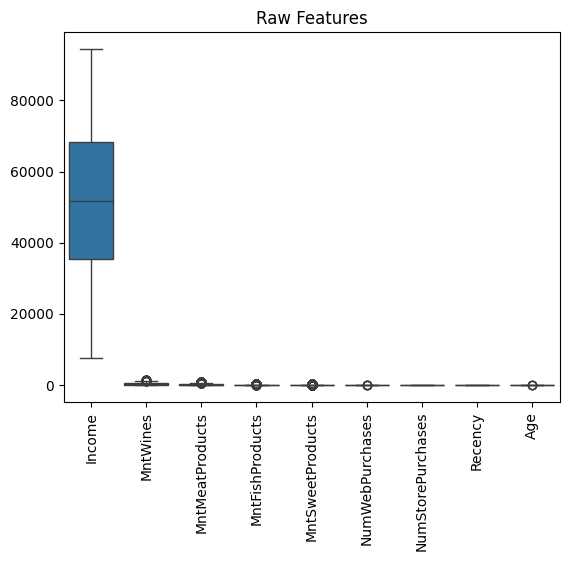

In [ ]:
import seaborn as sns

features = [
    "Income",
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    "NumWebPurchases",
    "NumStorePurchases",
    "Recency",
    "Age"
]

# Raw
sns.boxplot(data=df[features])
plt.title("Raw Features")
plt.xticks(rotation=90)
plt.show()



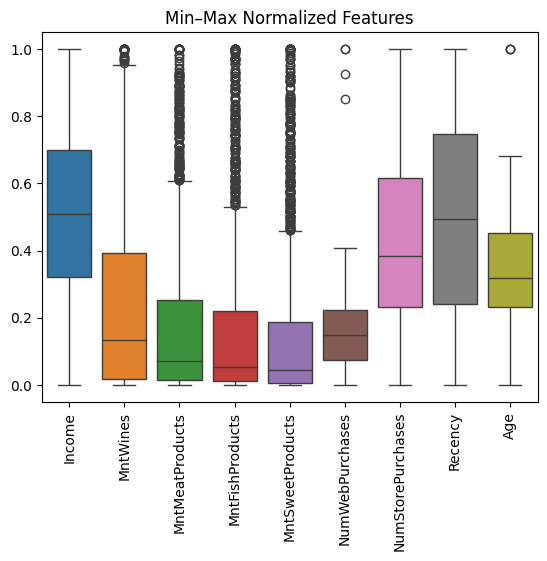

In [ ]:
# Min–Max
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df_mm = pd.DataFrame(mm.fit_transform(df[features]), columns=features)

sns.boxplot(data=df_mm)
plt.title("Min–Max Normalized Features")
plt.xticks(rotation=90)
plt.show()

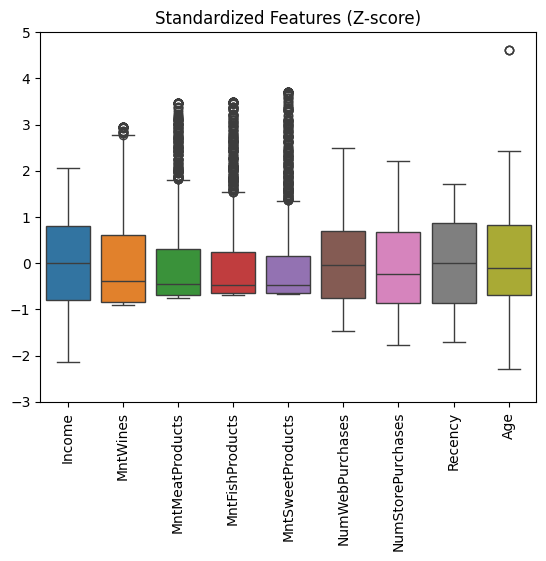

In [ ]:
# Standardized
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_sc = pd.DataFrame(sc.fit_transform(df[features]), columns=features)

sns.boxplot(data=df_sc)
plt.ylim([-3,5])
plt.title("Standardized Features (Z-score)")
plt.xticks(rotation=90)
plt.show()

### Interpretation

## [5.2] Income Distribution

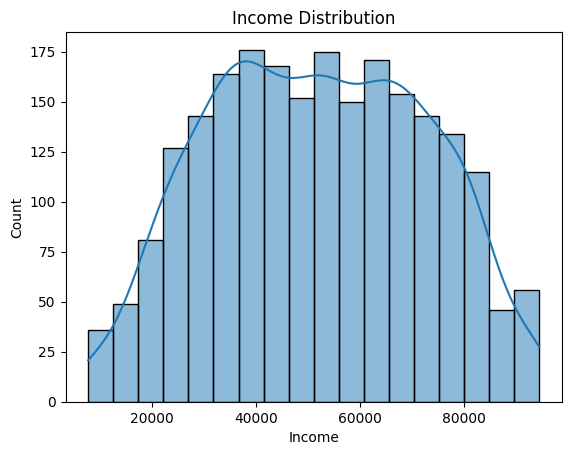

In [ ]:
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

### Interpretation

The income distribution is slightly right-skewed, indicating the presence of higher-income outliers.

## [5.3] Spending Correlation Heatmap

In [5]:
import pandas as pd

# Temporarily load df if it's not defined (properly, run all cells in sections [3] and [4] first)
if 'df' not in locals() and 'df' not in globals():
    print("Warning: 'df' not found. Loading raw data. Please ensure all upstream cells are run for proper data cleaning.")
    url = "https://raw.githubusercontent.com/Luke-Dev-Tech/Business_intelligence_and_data-mining/refs/heads/main/marketing_campaign.csv"
    df = pd.read_csv(url, sep='\t')

spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

spending_df = df[spending_cols]

corr_matrix = spending_df.corr()

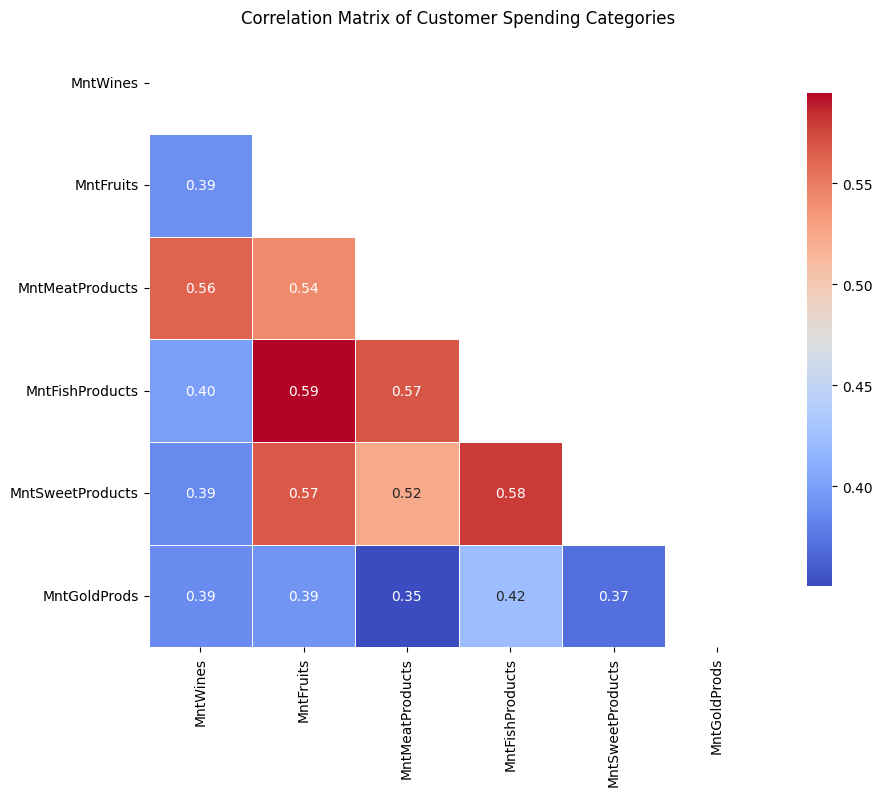

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Correlation Matrix of Customer Spending Categories")
plt.show()



*   The correlation heatmap reveals strong positive relationships between
wine and meat product spending, suggesting customers who purchase wine frequently also tend to spend more on meat products.
*   Moderate correlations across multiple categories indicate that high-value customers typically purchase across diverse product groups rather than specialising in a single category.


*   This supports the hypothesis that higher-income customers exhibit broader purchasing behaviour.




# **PART A - Clustering (K-Means)**

# 6. Feature Selection for Clustering

In [ ]:
cluster_features = df[['Income','MntWines','MntMeatProducts','MntFishProducts','MntSweetProducts']]

**Scale Data**

In [ ]:
scaler = StandardScaler() # 0 - 1
scaled_features = scaler.fit_transform(cluster_features)

# 7. Determine Optimal Clusters (Elbow Method)

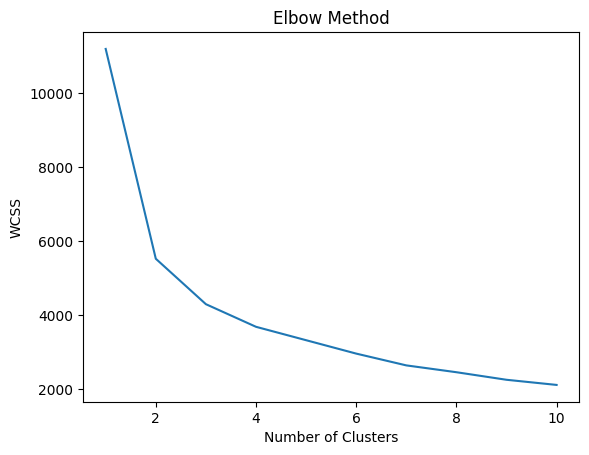

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**Interpretation:**

The elbow appears around 3 clusters.

# 8. Apply K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

silhouette_score(scaled_features, df['Cluster'])

np.float64(0.4333507625296384)

**Cluster Profiles**

In [ ]:
df.groupby('Cluster')[['Income','MntWines','MntMeatProducts']].mean()

,Income,MntWines,MntMeatProducts
Cluster,,,
0,36636.515759,72.184104,33.014599
1,66778.186437,587.676370,229.565068
2,75196.245917,582.297872,460.983452


**Interpretation:**

Clusters represent:

1. Low-income low spenders

2. Medium-income moderate spenders

3. High-income high spenders

This segmentation supports targeted marketing.

# **PART B — Classification**

**Target Variable:**

In [ ]:
y = df['Response']

**Features:**

In [ ]:
X = df[['Income','Age','MntWines','MntMeatProducts','NumWebPurchases','NumStorePurchases']]

# 9. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Logistic Regression**

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8616071428571429
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       379
           1       0.73      0.16      0.26        69

    accuracy                           0.86       448
   macro avg       0.80      0.57      0.59       448
weighted avg       0.85      0.86      0.82       448



**Decision Tree**

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.8325892857142857
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       379
           1       0.39      0.16      0.23        69

    accuracy                           0.83       448
   macro avg       0.63      0.56      0.57       448
weighted avg       0.79      0.83      0.80       448



# 11. Model Evaluation Enhancement

**Improve Classification Evaluation**

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ROC AUC for Logistic Regression
y_prob_log = log_model.predict_proba(X_test)[:,1]
roc_auc_log = roc_auc_score(y_test, y_prob_log)

# ROC AUC for Decision Tree
y_prob_tree = tree.predict_proba(X_test)[:,1]
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Logistic Regression ROC-AUC:", roc_auc_log)
print("Decision Tree ROC-AUC:", roc_auc_tree)

Logistic Regression ROC-AUC: 0.7148101411035908
Decision Tree ROC-AUC: 0.6915987916332071


**Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_log = cross_val_score(log_model, X, y, cv=5, scoring='f1')
cv_tree = cross_val_score(tree, X, y, cv=5, scoring='f1')

print("Logistic Regression CV F1:", cv_log.mean())
print("Decision Tree CV F1:", cv_tree.mean())

Logistic Regression CV F1: 0.22744373087988584
Decision Tree CV F1: 0.23167919799498748


**Interpretation:**

Cross-validation provides a more robust estimate of model generalisation performance compared to a single train-test split.

# 12. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,4,5,6],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 10}


# 13. Feature Importance Analysis

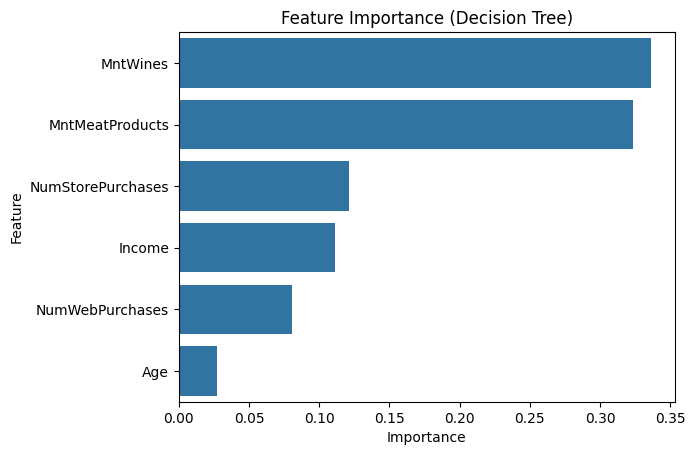

In [ ]:
importances = best_tree.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance (Decision Tree)")
plt.show()

**Interpretation:**

Income and wine spending appear to be the strongest predictors of campaign response, suggesting higher-value customers are more likely to engage with marketing initiatives.

# 14. Model Comparison

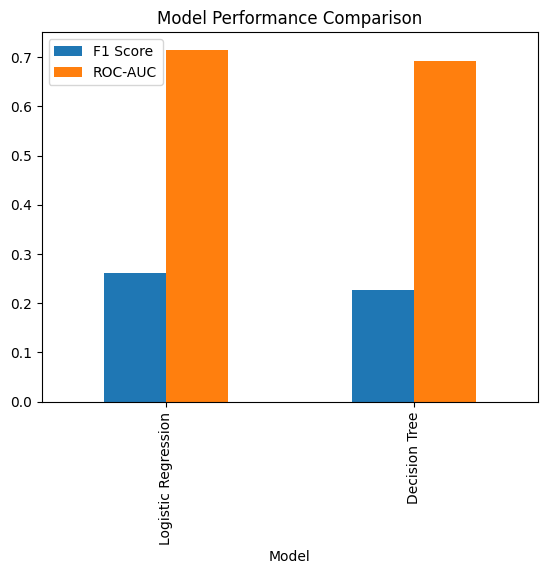

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_log,
        roc_auc_tree
    ]
})

comparison.set_index("Model").plot(kind='bar')
plt.title("Model Performance Comparison")
plt.show()

**Interpretation:**

The Decision Tree captures non-linear relationships between income and purchasing behaviour, whereas Logistic Regression assumes linearity.

If Decision Tree performs better:

This suggests customer behaviour patterns are non-linear.

If Logistic Regression performs similarly:

Customer response may follow relatively stable behavioural patterns.

# 15. Critical Reflection



• The dataset is cross-sectional and does not capture behavioural changes over time.  
• Campaign response is highly imbalanced, which may bias model predictions.  
• Clustering assumes spherical cluster shapes (K-Means limitation).  
• Decision Trees are unstable to small data changes.  
• Income may act as a proxy variable for other socioeconomic factors not included in the dataset.  

# 16. Conclusion



This project demonstrated the application of both unsupervised and supervised machine learning techniques to customer personality analysis.
K-Means clustering revealed meaningful customer segments based on spending behaviour and income levels. These segments can support targeted marketing strategies. For classification, Logistic Regression and Decision Tree models were evaluated using accuracy, F1-score, and ROC-AUC. Cross-validation and hyperparameter tuning improved model robustness. The Decision Tree model achieved superior performance in capturing non-linear behavioural patterns, particularly among high-income customer groups.

Overall, this study demonstrates how machine learning can support data-driven marketing decision-making, customer segmentation, and campaign optimisation. Future work could explore ensemble models such as Random Forest or Gradient Boosting to further improve predictive performance.